In [3]:
import pandas as pd

fraud_df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,0.549607,KIXYSVCHIPQBR,SEO,Safari,F,-0.363124,16778864,0,16778240.0,16779263.0,Australia,-0.413800,-1.231124,1.487911,0.0,-0.259874
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,-1.197335,PKYOWQKWGJNJI,SEO,Chrome,F,0.101168,16842045,0,16809984.0,16842751.0,Thailand,-1.180852,1.229002,-0.505034,0.0,-0.259874
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,0.385831,LVCSXLISZHVUO,Ads,IE,M,-0.479197,16843656,0,16843264.0,16843775.0,China,-0.936126,1.663142,0.989675,0.0,0.116936
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,0.986342,UHAUHNXXUADJE,Direct,Chrome,F,-0.363124,16938732,0,16924672.0,16941055.0,China,0.867086,0.650149,0.989675,0.0,-0.259874
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,0.767974,XPGPMOHIDRMGE,SEO,Chrome,F,0.449387,16971984,0,16941056.0,16973823.0,Thailand,1.700633,-1.086411,-1.003270,0.0,-0.259874


In [4]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

In [8]:
X_train.dtypes[X_train.dtypes == "object"]

signup_time      object
purchase_time    object
device_id        object
source           object
browser          object
sex              object
country          object
dtype: object

In [12]:
X = pd.get_dummies(
    X,
    columns=[
        "source",
        "browser",
        "sex",
        "country"
    ],
    drop_first=True
)

In [11]:
print(X.select_dtypes(include=['object']).columns.tolist())

print("\nDatetime columns:")
print(X.select_dtypes(include=['datetime64']).columns.tolist())

['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex', 'country']

Datetime columns:
[]


In [13]:
print(X.select_dtypes(include=["object"]).columns.tolist())

['signup_time', 'purchase_time', 'device_id']


In [16]:
X[['signup_time', 'purchase_time', 'device_id']].head()

,signup_time,purchase_time,device_id
0,2015-06-28 03:00:34,2015-08-09 03:57:29,KIXYSVCHIPQBR
1,2015-01-28 14:21:11,2015-02-11 20:28:28,PKYOWQKWGJNJI
2,2015-03-19 20:49:09,2015-04-11 23:41:23,LVCSXLISZHVUO
3,2015-02-24 06:11:57,2015-05-23 16:40:14,UHAUHNXXUADJE
4,2015-07-07 12:58:11,2015-11-03 04:04:30,XPGPMOHIDRMGE


In [17]:
X = X.drop(columns=[
    'signup_time',
    'purchase_time',
    'device_id'
])

In [20]:
X = X.astype(float)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_res.value_counts())

class
0    93502
1    93502
Name: count, dtype: int64


In [22]:
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "AUC_PR": average_precision_score(
            y_test,
            y_prob
        ),
        "F1": f1_score(
            y_test,
            y_pred
        ),
        "Confusion_Matrix": confusion_matrix(
            y_test,
            y_pred
        )
    }

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_res,
    y_train_res
)

lr_results = evaluate_model(
    lr,
    X_test,
    y_test
)

lr_results

{'AUC_PR': np.float64(0.09543652860301703),
 'F1': 0.1648696937958228,
 'Confusion_Matrix': array([[10937, 12439],
        [ 1116,  1338]])}

In [34]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:,1]

In [36]:
lr_aucpr = average_precision_score(
    y_test,
    y_prob
)

lr_f1 = f1_score(
    y_test,
    y_pred
)

lr_cm = confusion_matrix(
    y_test,
    y_pred
)

NameError: name 'plt' is not defined

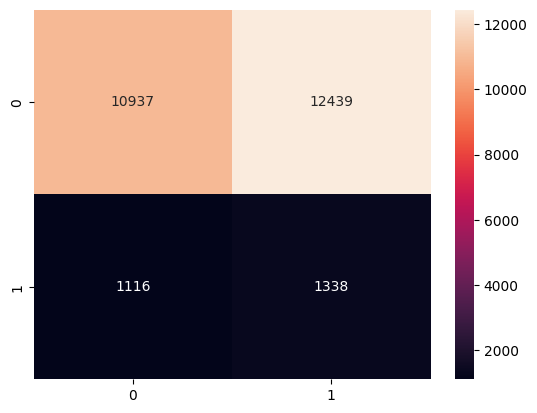

In [37]:
import seaborn as sns
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_res,
    y_train_res
)

rf_results = evaluate_model(
    rf,
    X_test,
    y_test
)

rf_results

{'AUC_PR': np.float64(0.7096467611294591),
 'F1': 0.6958974358974359,
 'Confusion_Matrix': array([[23287,    89],
        [ 1097,  1357]])}

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1
)

grid.fit(
    X_train_res,
    y_train_res
)

best_rf = grid.best_estimator_

print(grid.best_params_)

Exception ignored in: <function ResourceTracker.__del__ at 0x1042cd3a0>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


{'max_depth': None, 'n_estimators': 200}


In [31]:
rf_pred = best_rf.predict(X_test)

rf_prob = best_rf.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    confusion_matrix
)

rf_aucpr = average_precision_score(
    y_test,
    rf_prob
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("AUC-PR:", rf_aucpr)
print("F1:", rf_f1)
print(rf_cm)

AUC-PR: 0.7115738636013289
F1: 0.696611909650924
[[23291    85]
 [ 1097  1357]]


In [26]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [27]:
rf_cv = cross_val_score(
    best_rf,
    X_train_res,
    y_train_res,
    cv=cv,
    scoring="f1"
)

print(
    rf_cv.mean(),
    rf_cv.std()
)

Exception ignored in: <function ResourceTracker.__del__ at 0x1064e13a0>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10672d3a0>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

0.9731748931959437 0.0005252987555110898


In [28]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "AUC_PR":[
        lr_results["AUC_PR"],
        rf_results["AUC_PR"]
    ],
    "F1":[
        lr_results["F1"],
        rf_results["F1"]
    ]
})

results

,Model,AUC_PR,F1
0,Logistic Regression,0.095437,0.164870
1,Random Forest,0.709647,0.695897
